因为思路是尝试对数据进行切分，需要分别提取其中中等时间兴趣和短时间兴趣的aid，因此下面首先对于数据进行测试，试图得到session里aid长度分布范围以及对应TS的跨度信息。

In [ ]:
import pandas as pd
from pathlib import Path
import ast

TRAIN_PATH = Path(r"D:\pyproject\704\OOTO\restart\train.xlsx")

df = pd.read_excel(TRAIN_PATH)
print(f"总行数: {len(df)}")
if isinstance(df['events'].iloc[0], str):
    df['events'] = df['events'].apply(ast.literal_eval)

rows = []
for _, row in df.iterrows():
    for event in row['events']:
        rows.append({
            'session': row['session'],
            'aid': event['aid'],
            'ts': event['ts']
        })
df_expanded = pd.DataFrame(rows)

session_stats = df_expanded.groupby('session').agg(
    event_count=('aid', 'count'),
    ts_min=('ts', 'min'),
    ts_max=('ts', 'max')
).reset_index()

# 细节：原始时间戳是毫秒
MS_PER_DAY = 24 * 60 * 60 * 1000
session_stats['ts_range_days'] = (session_stats['ts_max'] - session_stats['ts_min']) / MS_PER_DAY

ts_ranges = session_stats['ts_range_days']
print(f"\nTS范围")
print(f"  最小值: {ts_ranges.min():.2f} 天")
print(f"  最大值: {ts_ranges.max():.2f} 天")

event_counts = session_stats['event_count']
print(f"\nEvent长度")
print(f"  最小值: {event_counts.min()}")
print(f"  最大值: {event_counts.max()}")

总行数: 10000

TS范围
  最小值: 0.00 天
  最大值: 28.00 天

Event长度
  最小值: 2
  最大值: 495


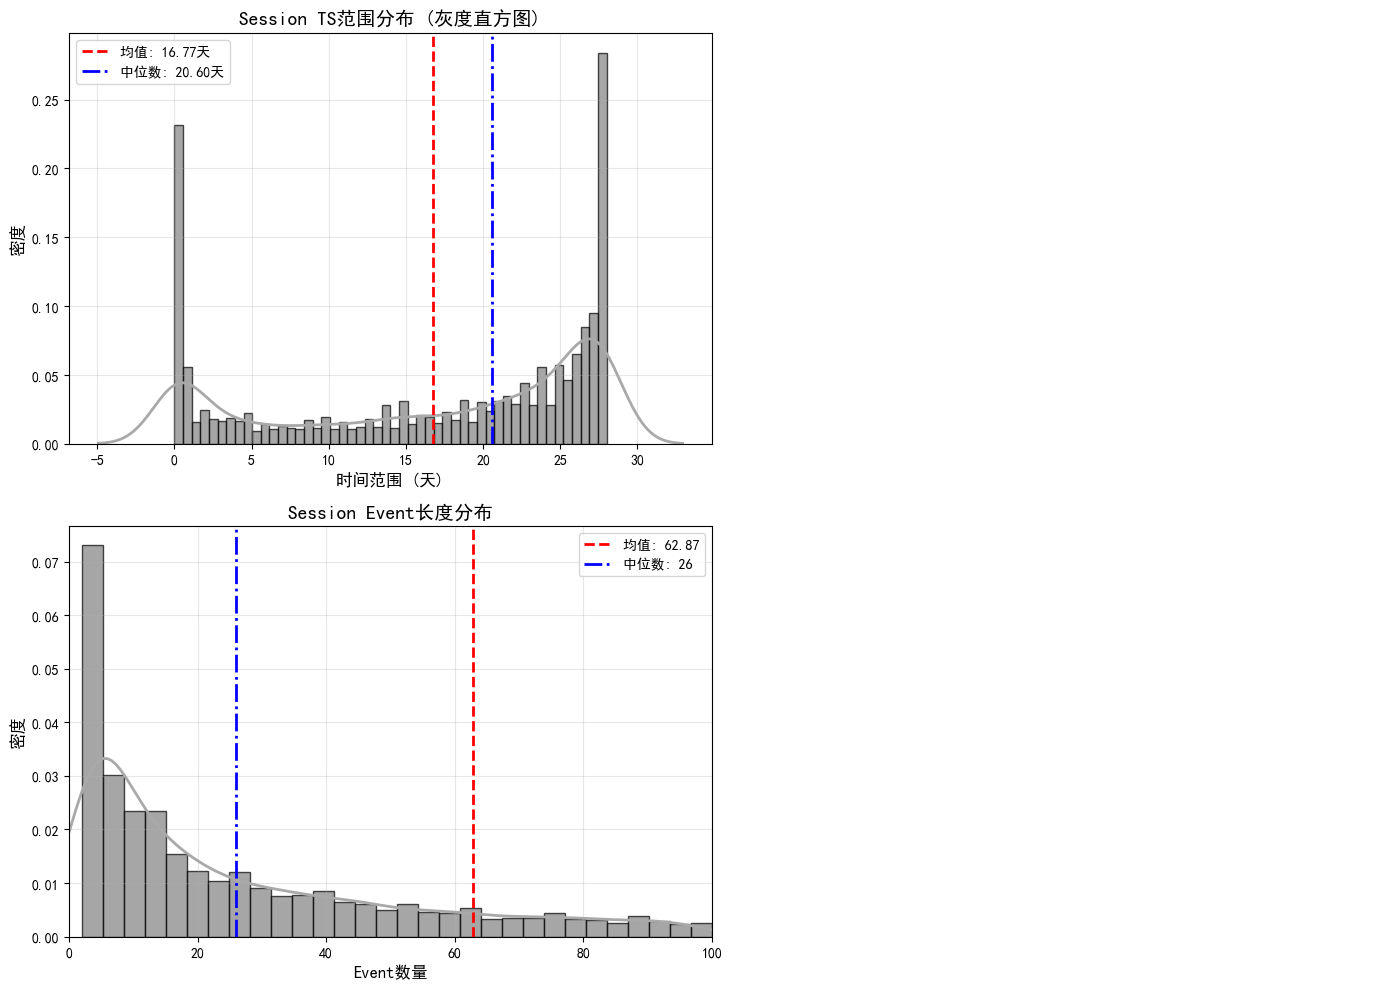


TS范围详细统计
样本数: 10000
均值: 16.7744 天
标准差: 10.3735 天
最小值: 0.0000 天
25%分位数: 6.5085 天
50%分位数 (中位数): 20.5997 天
75%分位数: 26.4896 天
95%分位数: 27.9041 天
99%分位数: 27.9808 天
最大值: 27.9999 天

Event长度详细统计
样本数: 10000
均值: 62.87
标准差: 85.29
最小值: 2
25%分位数: 8
50%分位数 (中位数): 26
75%分位数: 81
95%分位数: 263
99%分位数: 383
最大值: 495


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,1].axis('off')
axes[1,1].axis('off')
ax1 = axes[0, 0]
ts_data = session_stats['ts_range_days']   
ts_data_nonzero = ts_data[ts_data > 0]

if len(ts_data_nonzero) > 0:
    ax1.hist(ts_data_nonzero, bins=50, alpha=0.7, color='gray', edgecolor='black', density=True)
    sns.kdeplot(ts_data_nonzero, ax=ax1, color='darkgray', linewidth=2)
    ax1.axvline(ts_data_nonzero.mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {ts_data_nonzero.mean():.2f}天')
    ax1.axvline(ts_data_nonzero.median(), color='blue', linestyle='-.', linewidth=2, label=f'中位数: {ts_data_nonzero.median():.2f}天')
else:
    ax1.hist(ts_data, bins=50, alpha=0.7, color='gray', edgecolor='black')
    ax1.axvline(ts_data.mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {ts_data.mean():.2f}天')
    ax1.axvline(ts_data.median(), color='blue', linestyle='-.', linewidth=2, label=f'中位数: {ts_data.median():.2f}天')

ax1.set_xlabel('时间范围 (天)', fontsize=12)
ax1.set_ylabel('密度', fontsize=12)
ax1.set_title('Session TS范围分布 (灰度直方图)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax3 = axes[1, 0]
event_data = session_stats['event_count']
max_val = event_data.max()
if max_val > 100:
    event_data_trimmed = event_data[event_data <= 100]
    ax3.hist(event_data_trimmed, bins=30, alpha=0.7, color='gray', edgecolor='black', density=True)
    sns.kdeplot(event_data_trimmed, ax=ax3, color='darkgray', linewidth=2)
    ax3.set_xlim(0, 100)
else:
    ax3.hist(event_data, bins=30, alpha=0.7, color='gray', edgecolor='black', density=True)
    sns.kdeplot(event_data, ax=ax3, color='darkgray', linewidth=2)

ax3.axvline(event_data.mean(), color='red', linestyle='--', linewidth=2, label=f'均值: {event_data.mean():.2f}')
ax3.axvline(event_data.median(), color='blue', linestyle='-.', linewidth=2, label=f'中位数: {event_data.median():.0f}')
ax3.set_xlabel('Event数量', fontsize=12)
ax3.set_ylabel('密度', fontsize=12)
ax3.set_title('Session Event长度分布', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



print("\n" + "="*60)
print("TS范围详细统计")
print("="*60)
print(f"样本数: {len(ts_data)}")
print(f"均值: {ts_data.mean():.4f} 天")
print(f"标准差: {ts_data.std():.4f} 天")
print(f"最小值: {ts_data.min():.4f} 天")
print(f"25%分位数: {ts_data.quantile(0.25):.4f} 天")
print(f"50%分位数 (中位数): {ts_data.median():.4f} 天")
print(f"75%分位数: {ts_data.quantile(0.75):.4f} 天")
print(f"95%分位数: {ts_data.quantile(0.95):.4f} 天")
print(f"99%分位数: {ts_data.quantile(0.99):.4f} 天")
print(f"最大值: {ts_data.max():.4f} 天")


print("\n" + "="*60)
print("Event长度详细统计")
print("="*60)
print(f"样本数: {len(event_data)}")
print(f"均值: {event_data.mean():.2f}")
print(f"标准差: {event_data.std():.2f}")
print(f"最小值: {event_data.min()}")
print(f"25%分位数: {event_data.quantile(0.25):.0f}")
print(f"50%分位数 (中位数): {event_data.median():.0f}")
print(f"75%分位数: {event_data.quantile(0.75):.0f}")
print(f"95%分位数: {event_data.quantile(0.95):.0f}")
print(f"99%分位数: {event_data.quantile(0.99):.0f}")
print(f"最大值: {event_data.max()}")



可以发现，原始数据集中，event的长度跨度大，ts跨度相对稳定，因此以时间划分长/短时间兴趣建模会比较合适。同时，根据25%分位数和50%分位数，可以选择取7天为短时间，21天为中等时间。
同时，正样本选择最后一个ts往前24h内的aid，负样本最多为正样本的5倍。